In [13]:
import pandas as pd

data = pd.read_csv("city_day.csv")
data.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [14]:
# Checking for missing values
data.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [15]:
data.dropna(axis=0, inplace=True)

In [16]:
import plotly.express as px

# Converting 'Date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# AQI Trend Over Time
fig1 = px.line(data, x='Date', y='AQI', color='City', title='AQI Trend Over Time')
fig1.show()

# AQI Distribution by City
fig2 = px.box(data, x='City', y='AQI', title='AQI Distribution by City')
fig2.update_layout(xaxis={'categoryorder':'total descending'})
fig2.show()

# Scatter Plot Matrix for selected features
selected_features = ['PM2.5', 'NO2', 'CO', 'O3', 'AQI']
fig3 = px.scatter_matrix(data[selected_features], title='Scatter Plot Matrix')
fig3.show()

In [5]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_columns = [
    'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
    'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene'
]

# Features (X) and target (y)
X = data[feature_columns]
y = data['AQI']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardize the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

In [19]:
import tensorflow as tf

# Define the neural network
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

# Reduce learning rate when validation loss stops improving
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

# Stop training when validation loss stops improving
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

Epoch 1/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 24442.6816 - val_loss: 16747.4043 - learning_rate: 0.0010
Epoch 2/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7939.4697 - val_loss: 4663.1313 - learning_rate: 0.0010
Epoch 3/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3547.1272 - val_loss: 2956.1187 - learning_rate: 0.0010
Epoch 4/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2338.8330 - val_loss: 1950.5706 - learning_rate: 0.0010
Epoch 5/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1677.1715 - val_loss: 1406.4677 - learning_rate: 0.0010
Epoch 6/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1325.3016 - val_loss: 1136.9154 - learning_rate: 0.0010
Epoch 7/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1138.8751 - val_loss: 992.7244 - learning_rate: 0.0010
Epoch 8/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1035.8962 - val_loss: 902.1417 - learning_rate: 0.0010
Epoch 9/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 959

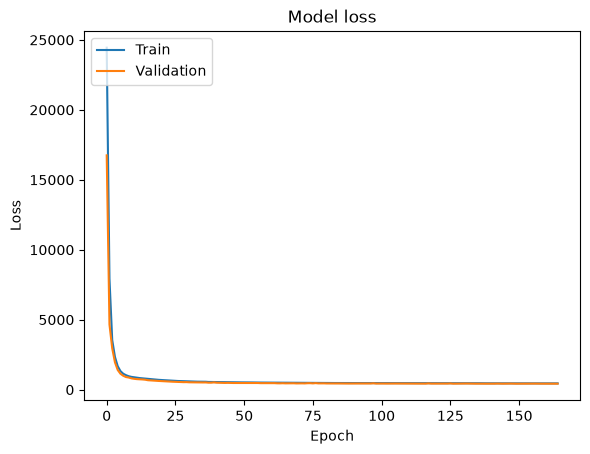

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 455.8786
Mean Squared Error on Test Data: 455.87860107421875


In [22]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Evaluate the model
loss = model.evaluate(X_test_scaled, y_test)
print("Mean Squared Error on Test Data:", loss)

In [23]:
model.save('model.h5')
user_input = pd.DataFrame({
    'PM2.5': [81],
    'PM10': [124],
    'NO': [1.44],
    'NO2': [20],
    'NOx': [12],
    'NH3': [10],
    'CO': [0.1],
    'SO2': [15],
    'O3': [127],
    'Benzene': [0.20],
    'Toluene': [6],
    'Xylene': [0.06]
})

user_input_scaled = scaler.transform(user_input)

user_pred = model.predict(user_input_scaled)

print(f"Predicted AQI: {user_pred[0][0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Predicted AQI: 194.04652404785156
